<a href="https://colab.research.google.com/github/Salma-Salah420/E-commerce-Data-analysis-and-visualization-project/blob/main/E_commerce_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **E-commerce preprocessing**



## **Part 1**

**I need to Access Data On Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


import gdown

file_id = "1pdlY-Q_dPrc9MEO10gsZiizFrBqA_QPu"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1pdlY-Q_dPrc9MEO10gsZiizFrBqA_QPu
To: /content/data.csv
100%|██████████| 2.29M/2.29M [00:00<00:00, 27.4MB/s]


'data.csv'

In [3]:
import os

os.listdir()

['.config', 'data.csv', 'drive', 'sample_data']

In [4]:
import pandas as pd

df = pd.read_csv("data.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Data Exploaration**

In [5]:
df.shape

(9994, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**There is no Duplicates and no null values**

In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
type("order Date")

str

**We should convert date from String to Datetime**

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

**Feature Engineering**

**Extract Shipping Time by this equation**

In [12]:
df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days

**We calculate profit Margin**

In [13]:
df['Profit Margin'] = df['Profit'] / df['Sales']

**Extract years and Months from Date **

In [14]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

**We should treat the outliers**

In [15]:
df[['Sales', 'Profit', 'Discount']].dtypes

,0
Sales,float64
Profit,float64
Discount,float64


In [16]:
df[['Sales','Profit','Discount']].describe()

,Sales,Profit,Discount
count,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203
std,623.245101,234.260108,0.206452
min,0.444000,-6599.978000,0.000000
25%,17.280000,1.728750,0.000000
50%,54.490000,8.666500,0.200000
75%,209.940000,29.364000,0.200000
max,22638.480000,8399.976000,0.800000


**Discount is unbalanced as minimum is 15% and maximum 75% so I think maximum discount can lead to the big loss in Profit**

**Profit I notice that there is big damage or big loss and at the same time there is huge profit as min is negative value**

**Sales has huge outliers as mean is too big than median as the data is Right Skewed**

**there are 1871 rows represents Loss**

In [17]:
df[df['Profit'] < 0].shape

(1871, 25)

**922 rows represent a big discount**

In [18]:
df[df['Discount'] >= 0.5].shape

(922, 25)

**Outliers I cannot delete them as they are important for Buisness**

**Product Cateogries**

In [19]:
df['Category'] = df['Category'].str.strip().str.lower()
df['Sub-Category'] = df['Sub-Category'].str.strip().str.lower()

In [20]:
df.duplicated(subset=['Product Name']).sum()

np.int64(8144)

In [21]:
df[df.duplicated(subset=['Product Name'], keep=False)].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Time,Profit Margin,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,0.1600,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,0.3000,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,0.4700,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-0.4000,2015,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,0.1125,2015,10


In [22]:
df[df['Product Name'] == df['Product Name'].iloc[0]]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Time,Profit Margin,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,bookcases,Bush Somerset Collection Bookcase,261.960,2,0.00,41.9136,3,0.160000,2016,11
5399,5400,CA-2016-117681,2016-04-09,2016-04-14,Standard Class,HF-14995,Herbert Flentye,Consumer,United States,Los Angeles,...,bookcases,Bush Somerset Collection Bookcase,556.665,5,0.15,6.5490,5,0.011765,2016,4
8634,8635,CA-2017-159793,2017-08-25,2017-08-29,Standard Class,SV-20365,Seth Vernon,Consumer,United States,Philadelphia,...,bookcases,Bush Somerset Collection Bookcase,130.980,2,0.50,-89.0664,4,-0.680000,2017,8
9334,9335,CA-2017-110198,2017-05-01,2017-05-02,First Class,AG-10900,Arthur Gainer,Consumer,United States,Coral Springs,...,bookcases,Bush Somerset Collection Bookcase,314.352,3,0.20,-15.7176,1,-0.050000,2017,5


**Product Name is NOT a unique key,but order id is unique**

In [23]:
df['Sub-Category'].unique()

array(['bookcases', 'chairs', 'labels', 'tables', 'storage',
       'furnishings', 'art', 'phones', 'binders', 'appliances', 'paper',
       'accessories', 'envelopes', 'fasteners', 'supplies', 'machines',
       'copiers'], dtype=object)

In [24]:
df['Sub-Category'] = df['Sub-Category'].str.lower().str.strip()

In [25]:
df['Category'].isnull().sum()
df['Sub-Category'].isnull().sum()

np.int64(0)

**To explore our Categories and subcateogries**

In [26]:
df.groupby(['Category', 'Sub-Category']).size()

Category         Sub-Category
furniture        bookcases        228
                 chairs           617
                 furnishings      957
                 tables           319
office supplies  appliances       466
                 art              796
                 binders         1523
                 envelopes        254
                 fasteners        217
                 labels           364
                 paper           1370
                 storage          846
                 supplies         190
technology       accessories      775
                 copiers           68
                 machines         115
                 phones           889
dtype: int64

**Customer Segments**

In [27]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

**Segment_Corporate
Segment_Home Office
(Consumer  will be baseline)**

In [28]:
df = pd.get_dummies(df, columns=['Segment'], drop_first=True)

**Shipping Modes**

In [29]:
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [30]:
df['Ship Mode'] = df['Ship Mode'].str.strip().str.lower()

**Check Spelling**

In [31]:
df['Ship Mode'] = df['Ship Mode'].replace({
    'standard-class': 'standard class',
    'same day': 'same day'
})

In [32]:
df = pd.get_dummies(df, columns=['Ship Mode'], drop_first=True)

**Step1: Preprocessing is Finished**

In [33]:
df.to_csv('cleaned_data.csv', index=False)

## **Part 2**

# **Comparison Charts**

## Sales by Category

 **Technology leads in total sales, followed by Furniture, while Office Supplies records the lowest sales.**

Technology clearly dominates revenue generation, indicating stronger demand or higher-priced products compared to other categories.

<Axes: title={'center': 'Total Sales by Category'}, xlabel='Category'>

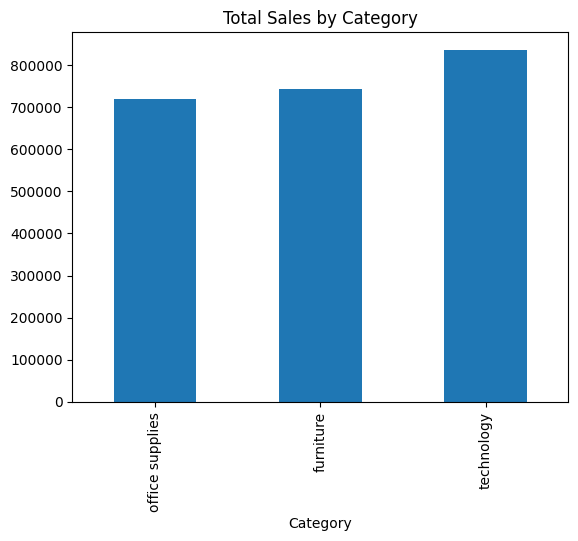

In [34]:
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='bar', title='Total Sales by Category')

## Profit by Sub-Category

**Copiers and Phones generate the highest profits, while Tables result in significant losses.**

Some sub-categories, despite generating sales, negatively impact overall profitability, highlighting inefficiencies in pricing or costs.

<Axes: ylabel='Sub-Category'>

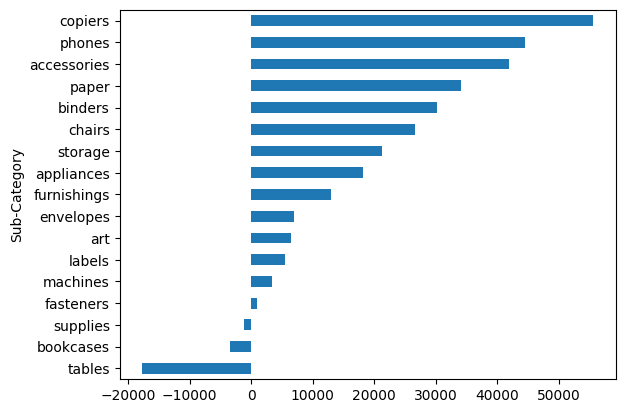

In [35]:
df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='barh')

## Sales by Segment

**The Consumer segment contributes the majority of total sales compared to other segments.**

Individual customers drive most of the revenue, making them the most important target group for the business.

<Axes: title={'center': 'Sales by Segment'}, xlabel='Segment_Corporate'>

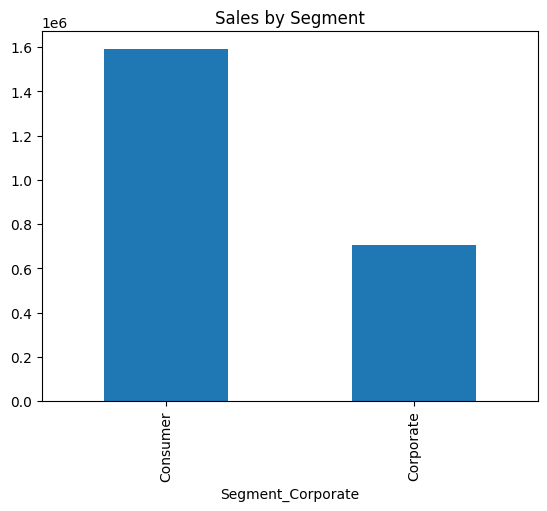

In [36]:
df.groupby(['Segment_Corporate'])['Sales'].sum().rename(index={False:'Consumer', True:'Corporate'}).plot(kind='bar', title='Sales by Segment')

## Sales by Category and Region

**Technology dominates across all regions, with relatively balanced contributions from each region.**

Sales distribution is consistent across regions, indicating no single region heavily outperforms others within categories.

NameError: name 'plt' is not defined

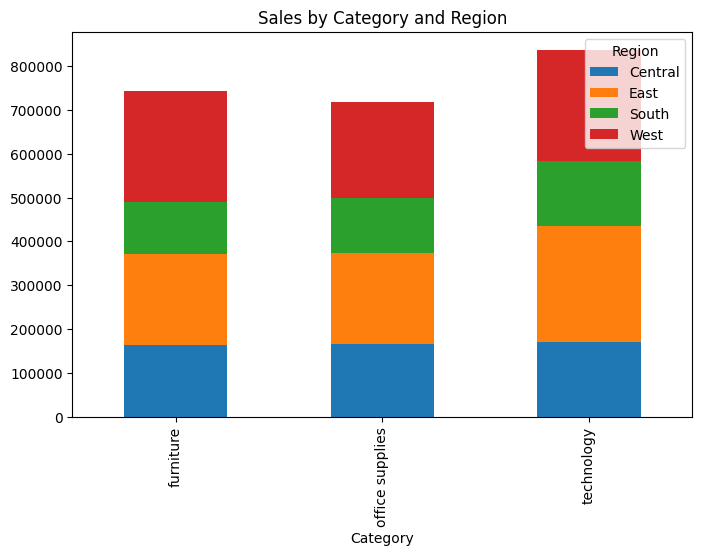

In [37]:
pivot = df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')
ax = pivot.plot(kind='bar', stacked=True, title='Sales by Category and Region', figsize=(8,5))

# Move legend outside
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## **Part 3**

# **Relationship Charts**

## Discount vs Profit

**Higher discounts are strongly associated with lower profits, often leading to losses.**

As discount levels increase, profit tends to decrease, with high discounts frequently resulting in negative profit values.

In [38]:
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True)

NameError: name 'plt' is not defined

## Sales vs Profit

**Higher sales generally lead to higher profits, but not always.**

While there is a positive trend, some high-sales transactions still result in losses, indicating inefficiencies or heavy discounts.

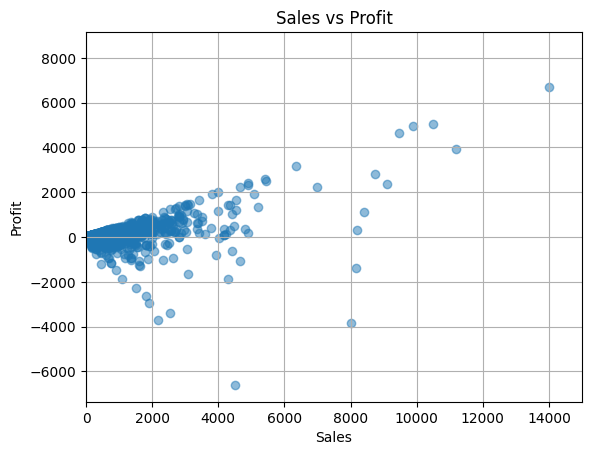

In [ ]:

plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.xlim(0, 15000)  # zoom for clarity
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)

## Shipping Time vs Profit

**Shipping time shows no clear impact on profit.**

Profit values are widely distributed across all shipping durations, suggesting that delivery time does not significantly influence profitability.

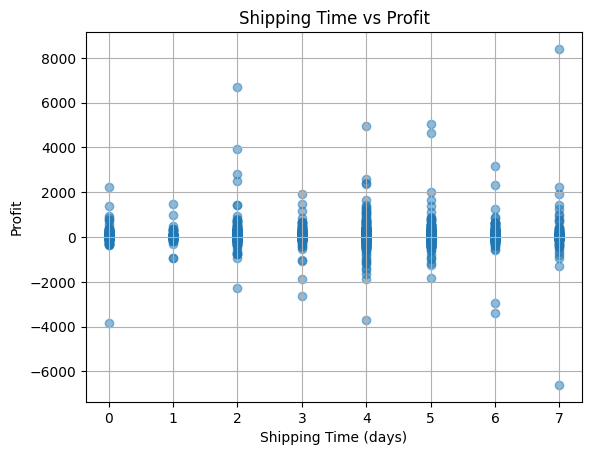

In [ ]:
plt.scatter(df['Shipping Time'], df['Profit'], alpha=0.5)
plt.title('Shipping Time vs Profit')
plt.xlabel('Shipping Time (days)')
plt.ylabel('Profit')
plt.grid(True)

## Sales vs Profit(Bubble = Quantity)

**Higher quantity orders amplify both profits and losses.**

Larger orders tend to increase impact on profit, but they can either boost gains or deepen losses depending on other factors.


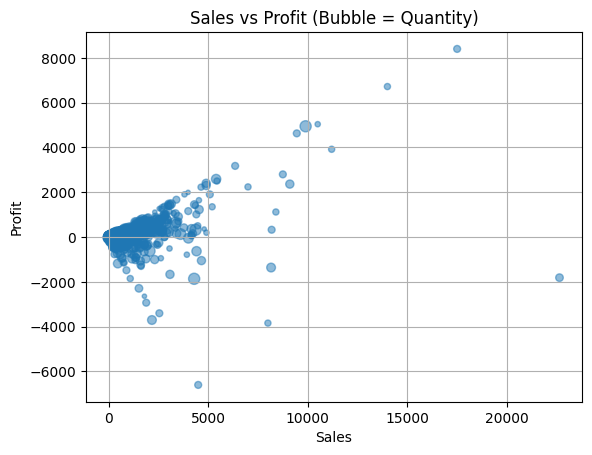

In [ ]:
plt.scatter(df['Sales'], df['Profit'], s=df['Quantity']*5, alpha=0.5)
plt.title('Sales vs Profit (Bubble = Quantity)')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.grid(True)

# **Part 4 — Distribution & Time-Series Charts**

This section covers **5 chart types**: Histogram, Box Plot, Violin Chart,
Line Chart, and Area Chart — built on the cleaned dataset from Part 1.


# Setup & Load Data

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')



In [40]:
sns.set_style('darkgrid')

BLUE   = '#2196F3'
ORANGE = '#FF5722'
GREEN  = '#4CAF50'
PURPLE = '#9C27B0'

COLORS = [
    '#2196F3', '#FF5722', '#4CAF50', '#9C27B0',
    '#FF9800', '#00BCD4', '#E91E63', '#607D8B',
    '#8BC34A', '#FF5252',
]

df = pd.read_csv('cleaned_data.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print('Dataset loaded:', df.shape)
df.head()


Dataset loaded: (9994, 28)


,Row ID,Order ID,Order Date,Ship Date,Customer ID,Customer Name,Country,City,State,Postal Code,...,Profit,Shipping Time,Profit Margin,Year,Month,Segment_Corporate,Segment_Home Office,Ship Mode_same day,Ship Mode_second class,Ship Mode_standard class
0,1,CA-2016-152156,2016-11-08,2016-11-11,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420,...,41.9136,3,0.1600,2016,11,False,False,False,True,False
1,2,CA-2016-152156,2016-11-08,2016-11-11,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420,...,219.5820,3,0.3000,2016,11,False,False,False,True,False
2,3,CA-2016-138688,2016-06-12,2016-06-16,DV-13045,Darrin Van Huff,United States,Los Angeles,California,90036,...,6.8714,4,0.4700,2016,6,True,False,False,True,False
3,4,US-2015-108966,2015-10-11,2015-10-18,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311,...,-383.0310,7,-0.4000,2015,10,False,False,False,False,True
4,5,US-2015-108966,2015-10-11,2015-10-18,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311,...,2.5164,7,0.1125,2015,10,False,False,False,False,True


# **Histogram**

#
## Distribution Charts
**Why this chart?**
A histogram visualises how a single numeric variable is distributed across its
range. Unlike the bar charts in Part 2 (which compared category totals),
a histogram reveals shape, spread, and outliers for individual transactions.

**Purpose:** Understand whether most orders are small or whether a few
large orders drive the majority of revenue.

**Expected insight:** The distribution will be right-skewed — most orders
cluster at lower values while a small number of very large transactions create
a long right tail. The mean will sit above the median, confirming the outlier
findings from Part 1.

 **Histogram: Distribution of Sales per Order**


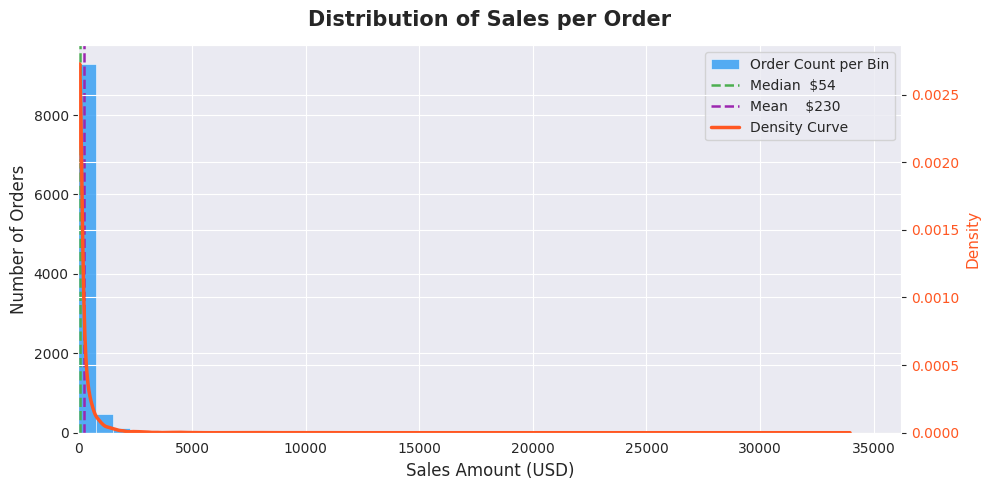


Sales Summary:
count     9994.00
mean       229.86
std        623.25
min          0.44
25%         17.28
50%         54.49
75%        209.94
max      22638.48
Name: Sales, dtype: float64


In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df['Sales'],
    bins=30,                   # guideline: start with 30, I follow it
    color=BLUE,
    alpha=0.75,
    edgecolor='white',
    linewidth=0.5,
    label='Order Count per Bin'
)

# KDE overlay on a secondary y-axis
ax2 = ax.twinx()
df['Sales'].plot.kde(ax=ax2, color=ORANGE, linewidth=2.5, label='Density Curve')
ax2.set_ylabel('Density', color=ORANGE, fontsize=11)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.set_ylim(bottom=0)        # prevent KDE from extending below zero

# Mean & Median reference lines
ax.axvline(df['Sales'].median(), color=GREEN,  linestyle='--', linewidth=1.8,
           label=f"Median  ${df['Sales'].median():,.0f}")
ax.axvline(df['Sales'].mean(),   color=PURPLE, linestyle='--', linewidth=1.8,
           label=f"Mean    ${df['Sales'].mean():,.0f}")

ax.set_title('Distribution of Sales per Order', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Sales Amount (USD)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_xlim(left=0)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nSales Summary:")
print(df['Sales'].describe().round(2))


**Insight:**
Most orders are low in value, with the majority falling below 500$. However, a small number of high-value transactions reaching up to $35,000 create a strong right skew, pulling the mean ($230) far above the median ($54). This suggests that while the store processes a high volume of small orders, a few large orders contribute disproportionately to total revenue.

# **Box Plot**

**Why this chart?**
A box plot is ideal for comparing a numeric variable across multiple groups —
it shows the five-number summary and flags individual outliers. This goes
beyond the category profit totals shown in Part 2 by revealing spread and risk.

**Purpose:** Compare profit consistency and variance across the three
categories to identify which carry the most business risk.

**Expected insight:** Technology should show the highest and most consistent
median profit. Furniture is expected to have a low median with a wide spread,
reflecting the aggressive discounting seen in Part 3.


**Box Plot: Profit Distribution by Product Category**


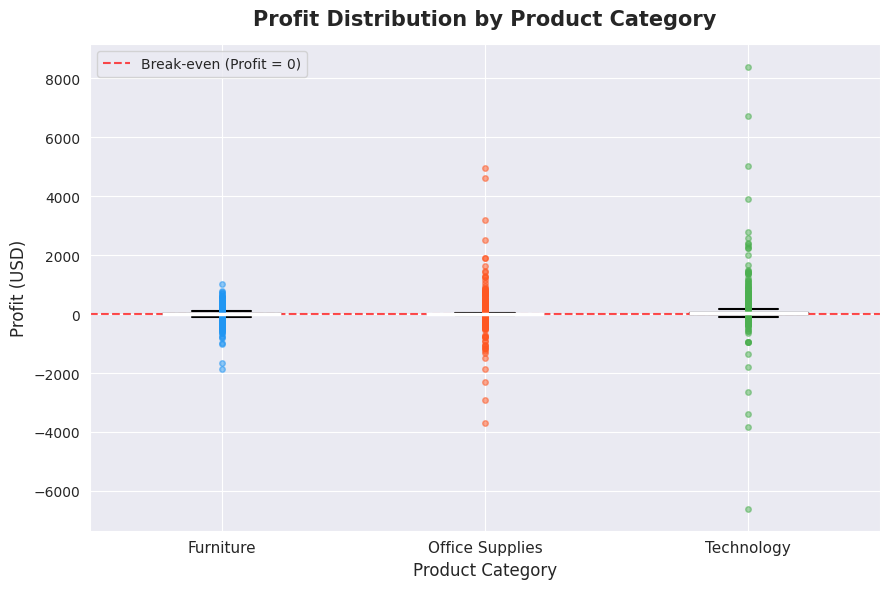


Profit Summary by Category:
                  count   mean     std      min    25%    50%    75%      max
Category                                                                     
furniture        2121.0   8.70  136.05 -1862.31 -12.85   7.77  33.73  1013.13
office supplies  6026.0  20.33  164.89 -3701.89   2.10   6.88  19.42  4946.37
technology       1847.0  78.75  428.82 -6599.98   5.20  25.02  74.89  8399.98


In [43]:
categories    = df['Category'].str.title().unique()
profit_groups = [df[df['Category'] == c.lower()]['Profit'].values for c in categories]

fig, ax = plt.subplots(figsize=(9, 6))

bp = ax.boxplot(
    profit_groups,
    patch_artist=True,         # filled boxes — required by lecture guideline
    notch=False,
    vert=True,                 # vertical: category labels are short
    widths=0.45,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

for patch, color in zip(bp['boxes'], COLORS[:len(categories)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for flier, color in zip(bp['fliers'], COLORS[:len(categories)]):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label='Break-even (Profit = 0)')

ax.set_title('Profit Distribution by Product Category', fontsize=15,
             fontweight='bold', pad=14)
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Profit (USD)', fontsize=12)
ax.set_xticks(range(1, len(categories) + 1))
ax.set_xticklabels([c.title() for c in categories], fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\nProfit Summary by Category:")
print(df.groupby('Category')['Profit'].describe().round(2))


## **Insight:**
**All three categories have a median profit close to zero, meaning most individual orders are marginally profitable. However, Technology shows the widest range of outliers, indicating it carries both the highest profit potential and the highest loss risk. Furniture consistently underperforms with losses clustered near the break-even line.**


# **Violin Chart**

**Why this chart?**
A violin chart adds a KDE curve to the box plot, making it possible to see
the full distribution shape — including bimodal patterns that five numbers
alone cannot capture.

**Purpose:** Check whether profit within each customer segment forms one
cluster or splits into two (profitable vs. loss-making orders).

**Expected insight:** If any segment shows two visible bulges — one above and
one below zero — it means losses are systematic in that group, not just
isolated outliers. This would extend the Discount vs Profit finding from
Part 3 to a segment-level explanation.


**Violin Chart: Profit Distribution by Customer Segment**

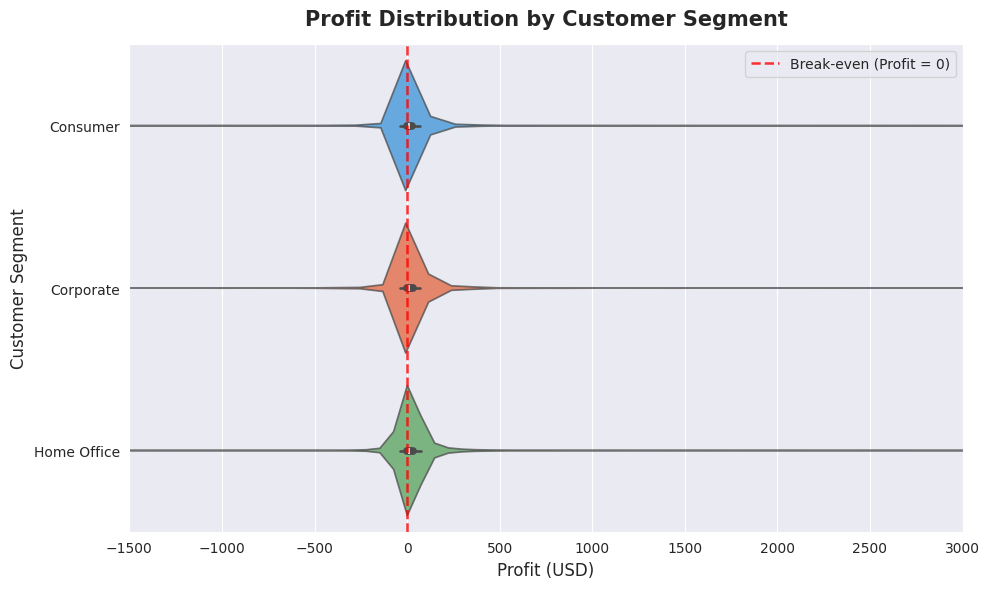


Profit Summary by Segment:
                count   mean     std      min   25%   50%    75%      max
Segment_Label                                                            
Consumer       5191.0  25.84  242.59 -6599.98  1.58  8.38  28.61  6719.98
Corporate      3020.0  30.46  231.99 -3839.99  1.93  8.69  29.84  8399.98
Home Office    1783.0  33.82  212.38 -3399.98  1.98  9.10  31.56  3919.99


In [44]:
# Reconstruct Segment label from the dummies created in Part 1
def get_segment(row):
    if row.get('Segment_Corporate', False):
        return 'Corporate'
    if row.get('Segment_Home Office', False):
        return 'Home Office'
    return 'Consumer'

df['Segment_Label'] = df.apply(get_segment, axis=1)

segment_order = ['Consumer', 'Corporate', 'Home Office']
palette = {seg: col for seg, col in zip(segment_order, COLORS)}

fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='Profit',
    y='Segment_Label',
    order=segment_order,
    orient='h',                # horizontal: labels are long
    inner='box',               # keep IQR box inside for reference
    cut=0,                     # limit KDE to actual data range
    palette=palette,
    alpha=0.75,
    ax=ax
)

ax.axvline(0, color='red', linestyle='--', linewidth=1.8, alpha=0.8,
           label='Break-even (Profit = 0)')

ax.set_title('Profit Distribution by Customer Segment', fontsize=15,
             fontweight='bold', pad=14)
ax.set_xlabel('Profit (USD)', fontsize=12)
ax.set_ylabel('Customer Segment', fontsize=12)
ax.set_xlim(-1500, 3000)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\nProfit Summary by Segment:")
print(df.groupby('Segment_Label')['Profit'].describe().round(2))


# **Insight:**

**All three customer segments show profit distributions tightly centered around zero, with no segment showing a clearly bimodal pattern. The Consumer segment has the widest spread, reflecting its larger order volume and higher variability. Losses exist across all segments but are not concentrated, suggesting they result from occasional heavy discounting rather than a structural pricing problem in any specific segment.**
